In [322]:
from functions_newparams import *
import matplotlib.ticker as ticker

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import colors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import FormatStrFormatter


%matplotlib widget

import corner
import h5py

import warnings
warnings.filterwarnings("ignore")

SHEN FIT CHI2 GRIDS:

5 Redshift values with M*crit vs post-disk sigma.

0.4999160064704361 (array([1]), array([16]), array([30]))
1.2307692307692308 4.6923076923076925 10.76923076923077
5.698316707196303 (array([4]), array([8]), array([27]))
1.9230769230769231 2.8461538461538463 10.192307692307693
7.0680080102168965 (array([4]), array([5]), array([28]))
1.9230769230769231 2.153846153846154 10.384615384615385
6.715412728535168 (array([4]), array([5]), array([28]))
1.9230769230769231 2.153846153846154 10.384615384615385
4.140721097711641 (array([5]), array([4]), array([26]))
2.153846153846154 1.9230769230769231 10.0


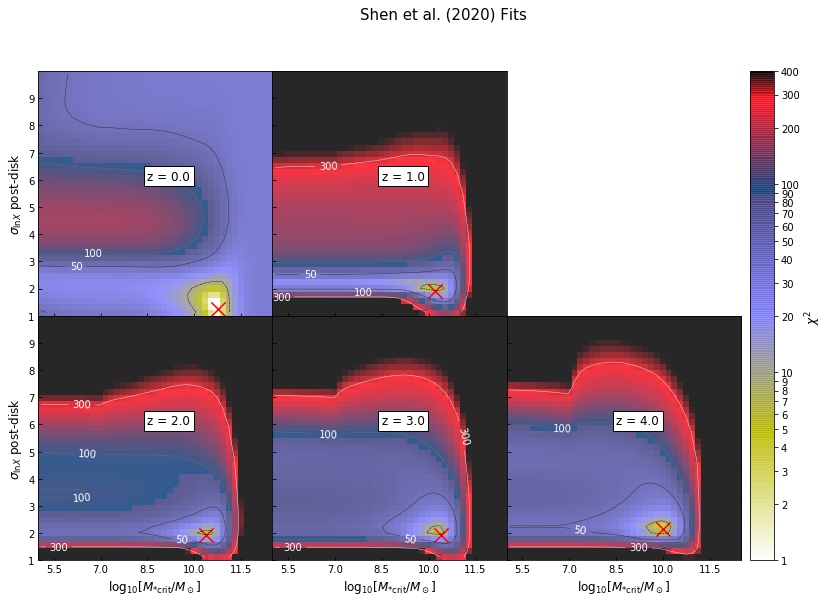

In [5]:
def CHI2_POSTvsCRIT(FILE = "output/chi2_3pShenfit_40_nw_mk3.h5py"):
    fig = plt.figure(figsize=(15,9))
    gs = gridspec.GridSpec(2, 3)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()

    stack = np.zeros((len(logMstar0 ), len(logMstar0 )))
                     
    zlist = [0.0,1.0,2.0,3.0,4.0]
    axi = [0,0,1,1,1]
    axj = [0,1,0,1,2]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)

    for z, i, j in zip(zlist, axi, axj):
        
        ### retrieveing specific redshift 
        f = h5py.File(FILE, "r")
        chi23d = np.transpose(f['z='+str(z)+'/chi23d_grid'][:])
        f.close()
        
        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)
        print(minval, minind)
        
        bestpost = siglnX2[minind[0][0]]
        bestpre = siglnX1[minind[1][0]]
        bestcrit = logMstar0[minind[2][0]]
        
        print(bestpost, bestpre, bestcrit)

                     
        ### set up axis and label info
        ylabel = r'$\sigma_{\ln{X}}$ post-disk'
        xlabel = r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$'
        axis = [5,12.5,1.0,10.0]
        extent = [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]]
                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.axis(axis)
        ax.tick_params(axis='both', direction='in')
        plt.setp(ax, xticks=np.linspace(5.5,11.5,5),
        yticks=[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0])
        
        grid2d = chi23d[:,minind[1][0],:]
        ax.scatter(bestcrit, bestpost, marker = 'x', c='r',s=200)
        
        norm = colors.LogNorm()
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, vmin = 1, vmax=400, alpha=0.85)
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,300],cmap='binary_r', vmin = 10, vmax = 400, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220))
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220),linestyles='dashed')
        ax.text(8.5,6,'z = '+str(z), bbox=props, fontsize=12)

    
    plt.suptitle('Shen et al. (2020) Fits',fontsize=15)        
    plt.subplots_adjust(wspace=0, hspace=0)
    
    plt.setp(axes_l[0].get_xticklabels(), visible=False)  
    plt.setp(axes_l[1].get_xticklabels(), visible=False)       
    
    axes_l[2].set_xlabel(xlabel,fontsize=12)
    axes_l[3].set_xlabel(xlabel,fontsize=12)
    axes_l[4].set_xlabel(xlabel,fontsize=12)
    axes_l[0].set_ylabel(ylabel,fontsize=12)
    axes_l[2].set_ylabel(ylabel,fontsize=12)
    
    plt.setp(axes_l[1].get_yticklabels(), visible=False)
    plt.setp(axes_l[3].get_yticklabels(), visible=False)
    plt.setp(axes_l[4].get_yticklabels(), visible=False)
    
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l, format="%d").set_label(label=r'$\chi ^2$ ',size=12)

    plt.savefig('plots/Chi2-plots/CHI2_SHEN_r40_post-v-crit.pdf')


CHI2_POSTvsCRIT()


SHEN FIT CHI2 GRIDS:

5 Redshift values with M*crit vs pre-disk sigma.

0.4999160064704361 (array([1]), array([16]), array([30]))
1.2307692307692308 4.6923076923076925 10.76923076923077
5.698316707196303 (array([4]), array([8]), array([27]))
1.9230769230769231 2.8461538461538463 10.192307692307693
7.0680080102168965 (array([4]), array([5]), array([28]))
1.9230769230769231 2.153846153846154 10.384615384615385
6.715412728535168 (array([4]), array([5]), array([28]))
1.9230769230769231 2.153846153846154 10.384615384615385
4.140721097711641 (array([5]), array([4]), array([26]))
2.153846153846154 1.9230769230769231 10.0


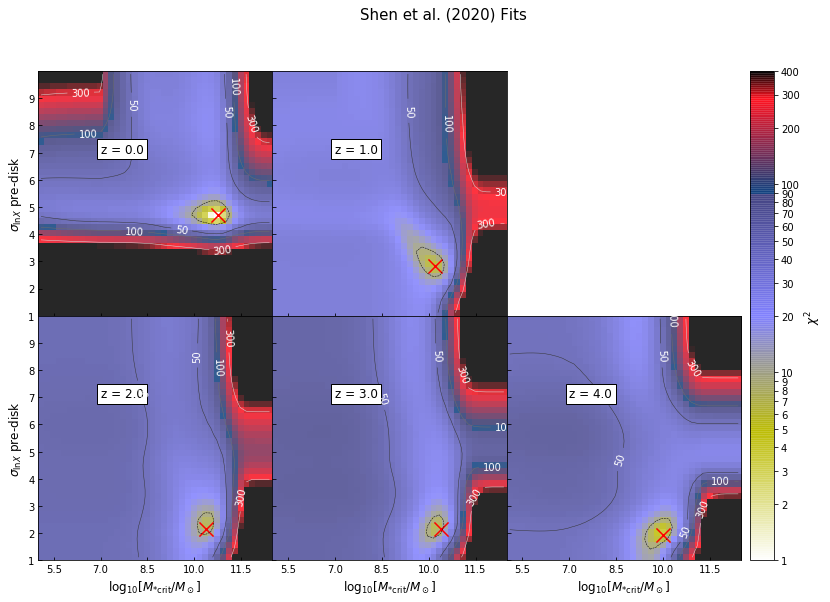

In [6]:
def CHI2_POSTvsCRIT(FILE = "output/chi2_3pShenfit_40_nw_mk3.h5py"):
    fig = plt.figure(figsize=(15,9))
    gs = gridspec.GridSpec(2, 3)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()

    stack = np.zeros((len(logMstar0 ), len(logMstar0 )))
                     
    zlist = [0.0,1.0,2.0,3.0,4.0]
    axi = [0,0,1,1,1]
    axj = [0,1,0,1,2]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)

    for z, i, j in zip(zlist, axi, axj):
        
        ### retrieveing specific redshift 
        f = h5py.File(FILE, "r")
        chi23d = np.transpose(f['z='+str(z)+'/chi23d_grid'][:])
        f.close()
        
        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)
        print(minval, minind)
        
        bestpost = siglnX2[minind[0][0]]
        bestpre = siglnX1[minind[1][0]]
        bestcrit = logMstar0[minind[2][0]]
        
        print(bestpost, bestpre, bestcrit)

                     
        ### set up axis and label info
        ylabel = r'$\sigma_{\ln{X}}$ pre-disk'
        xlabel = r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$'
        axis = [5,12.5,1.0,10.0]
        extent = [logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]]
                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.axis(axis)
        ax.tick_params(axis='both', direction='in')
        plt.setp(ax, xticks=np.linspace(5.5,11.5,5),
        yticks=[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0])
        
        grid2d = chi23d[minind[0][0],:,:]
        ax.scatter(bestcrit, bestpre, marker = 'x', c='r',s=200)
        
        norm = colors.LogNorm()
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, vmin = 1, vmax=400, alpha=0.85)
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,300],cmap='binary_r', vmin = 10, vmax = 400, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220))
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220),linestyles='dashed')
        ax.text(7,7,'z = '+str(z), bbox=props, fontsize=12)

    
    plt.suptitle('Shen et al. (2020) Fits',fontsize=15)        
    plt.subplots_adjust(wspace=0, hspace=0)
    
    plt.setp(axes_l[0].get_xticklabels(), visible=False)  
    plt.setp(axes_l[1].get_xticklabels(), visible=False)       
    
    axes_l[2].set_xlabel(xlabel,fontsize=12)
    axes_l[3].set_xlabel(xlabel,fontsize=12)
    axes_l[4].set_xlabel(xlabel,fontsize=12)
    axes_l[0].set_ylabel(ylabel,fontsize=12)
    axes_l[2].set_ylabel(ylabel,fontsize=12)
    
    plt.setp(axes_l[1].get_yticklabels(), visible=False)
    plt.setp(axes_l[3].get_yticklabels(), visible=False)
    plt.setp(axes_l[4].get_yticklabels(), visible=False)
    
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l, format="%d").set_label(label=r'$\chi ^2$ ',size=12)

    plt.savefig('plots/Chi2-plots/CHI2_SHEN_r40_pre-v-crit.pdf')


CHI2_POSTvsCRIT()


SHEN FIT CHI2 GRIDS:

5 Redshift values withpre-disk sigma vs post-disk sigma.

0.4999160064704361 (array([1]), array([16]), array([30]))
1.2307692307692308 4.6923076923076925 10.76923076923077
5.698316707196303 (array([4]), array([8]), array([27]))
1.9230769230769231 2.8461538461538463 10.192307692307693
7.0680080102168965 (array([4]), array([5]), array([28]))
1.9230769230769231 2.153846153846154 10.384615384615385
6.715412728535168 (array([4]), array([5]), array([28]))
1.9230769230769231 2.153846153846154 10.384615384615385
4.140721097711641 (array([5]), array([4]), array([26]))
2.153846153846154 1.9230769230769231 10.0


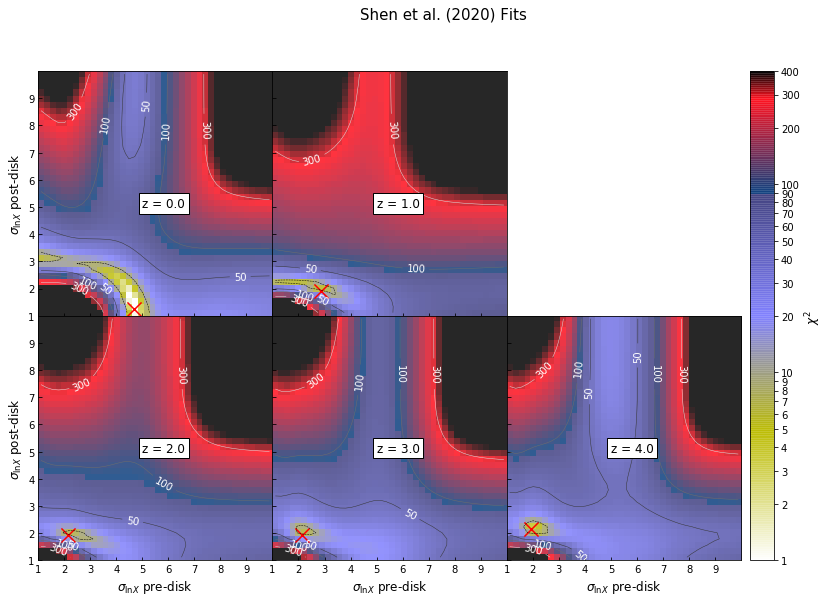

In [7]:
def CHI2_POSTvsCRIT(FILE = "output/chi2_3pShenfit_40_nw_mk3.h5py"):
    fig = plt.figure(figsize=(15,9))
    gs = gridspec.GridSpec(2, 3)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()

    stack = np.zeros((len(logMstar0 ), len(logMstar0 )))
                     
    zlist = [0.0,1.0,2.0,3.0,4.0]
    axi = [0,0,1,1,1]
    axj = [0,1,0,1,2]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)

    for z, i, j in zip(zlist, axi, axj):
        
        ### retrieveing specific redshift 
        f = h5py.File(FILE, "r")
        chi23d = np.transpose(f['z='+str(z)+'/chi23d_grid'][:])
        f.close()
        
        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)
        print(minval, minind)
        
        bestpost = siglnX2[minind[0][0]]
        bestpre = siglnX1[minind[1][0]]
        bestcrit = logMstar0[minind[2][0]]
        
        print(bestpost, bestpre, bestcrit)

                     
        ### set up axis and label info
        ylabel = r'$\sigma_{\ln{X}}$ post-disk'
        xlabel = r'$\sigma_{\ln{X}}$ pre-disk'
        axis = [1.0,10.0,1.0,10.0]
        extent = [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]]
                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.axis(axis)
        ax.tick_params(axis='both', direction='in')
        plt.setp(ax, xticks=[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0],
        yticks=[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0])
        
        grid2d = chi23d[:,:,minind[2][0]]
        ax.scatter(bestpre, bestpost, marker = 'x', c='r',s=200)
        
        norm = colors.LogNorm()
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, vmin = 1, vmax=400, alpha=0.85)
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,300],cmap='binary_r', vmin = 10, vmax = 400, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220))
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220),linestyles='dashed')
        ax.text(5,5,'z = '+str(z), bbox=props, fontsize=12)

    
    plt.suptitle('Shen et al. (2020) Fits',fontsize=15)        
    plt.subplots_adjust(wspace=0, hspace=0)
    
    plt.setp(axes_l[0].get_xticklabels(), visible=False)  
    plt.setp(axes_l[1].get_xticklabels(), visible=False)       
    
    axes_l[2].set_xlabel(xlabel,fontsize=12)
    axes_l[3].set_xlabel(xlabel,fontsize=12)
    axes_l[4].set_xlabel(xlabel,fontsize=12)
    axes_l[0].set_ylabel(ylabel,fontsize=12)
    axes_l[2].set_ylabel(ylabel,fontsize=12)
    
    plt.setp(axes_l[1].get_yticklabels(), visible=False)
    plt.setp(axes_l[3].get_yticklabels(), visible=False)
    plt.setp(axes_l[4].get_yticklabels(), visible=False)
    
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l, format="%d").set_label(label=r'$\chi ^2$ ',size=12)

    plt.savefig('plots/Chi2-plots/CHI2_SHEN_r40_pre-v-post.pdf')


CHI2_POSTvsCRIT()


SHEN FIT CHI2 GRIDS:

All redshift values for parameters pre-disk sigma, post-disk sigma, and M*crit in a multipage pdf.

0.4999160064704361 (array([1]), array([16]), array([30]))
1.2307692307692308 4.6923076923076925 10.76923076923077
0.4999160064704361 (array([1]), array([16]), array([30]))
1.2307692307692308 4.6923076923076925 10.76923076923077
0.4999160064704361 (array([1]), array([16]), array([30]))
1.2307692307692308 4.6923076923076925 10.76923076923077
5.698316707196303 (array([4]), array([8]), array([27]))
1.9230769230769231 2.8461538461538463 10.192307692307693
5.698316707196303 (array([4]), array([8]), array([27]))
1.9230769230769231 2.8461538461538463 10.192307692307693
5.698316707196303 (array([4]), array([8]), array([27]))
1.9230769230769231 2.8461538461538463 10.192307692307693
7.0680080102168965 (array([4]), array([5]), array([28]))
1.9230769230769231 2.153846153846154 10.384615384615385
7.0680080102168965 (array([4]), array([5]), array([28]))
1.9230769230769231 2.153846153846154 10.384615384615385
7.0680080102168965 (array([4]), array([5]), array([28]))
1.9230769230769231 2.153846153846154

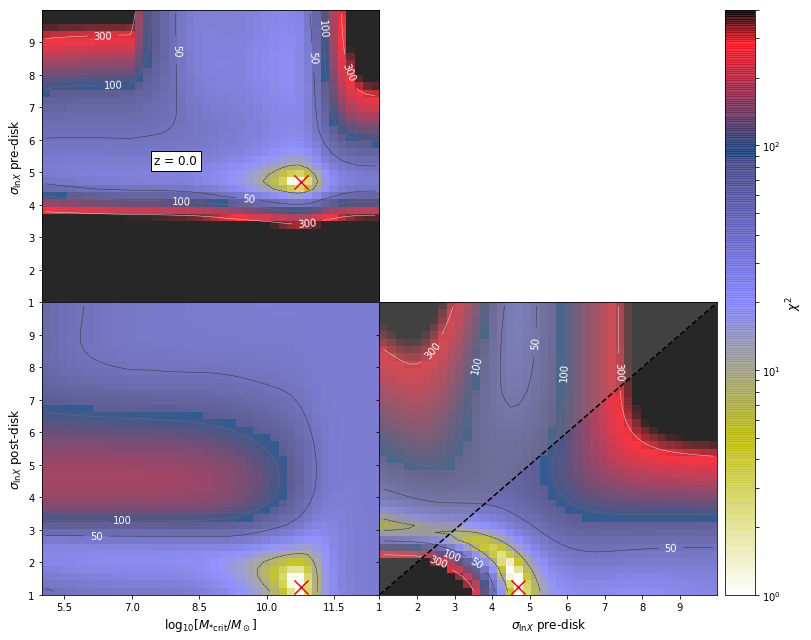

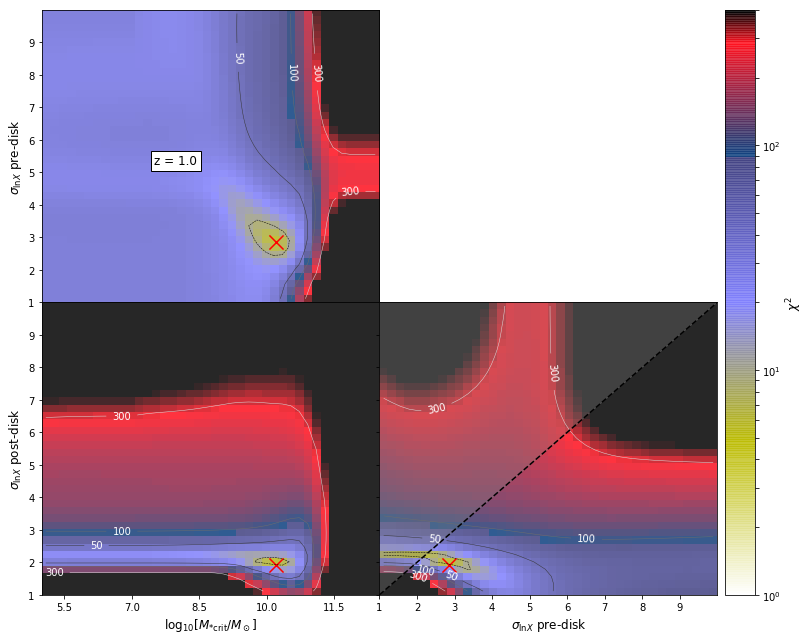

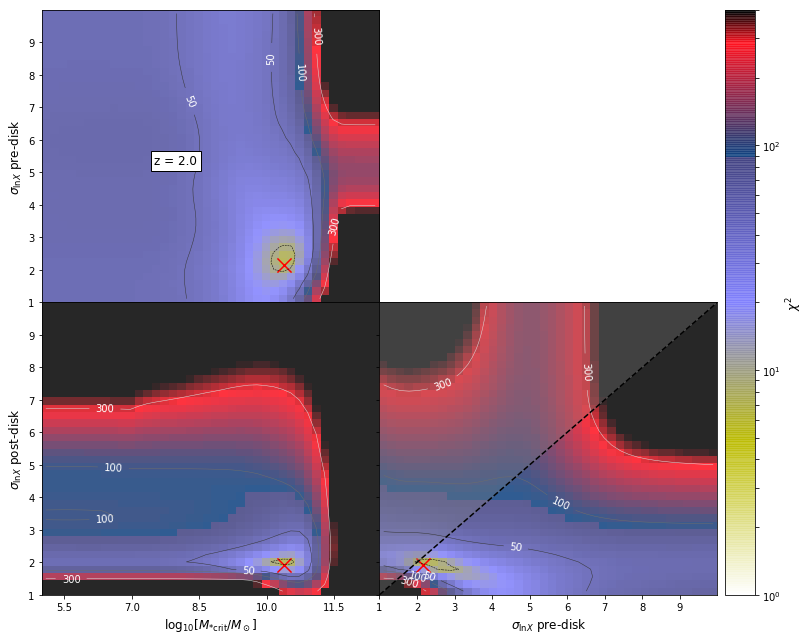

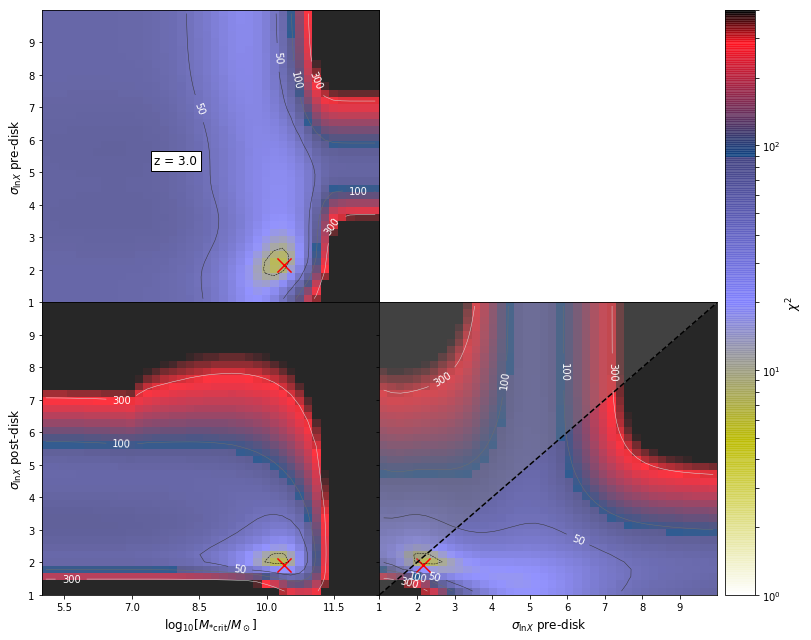

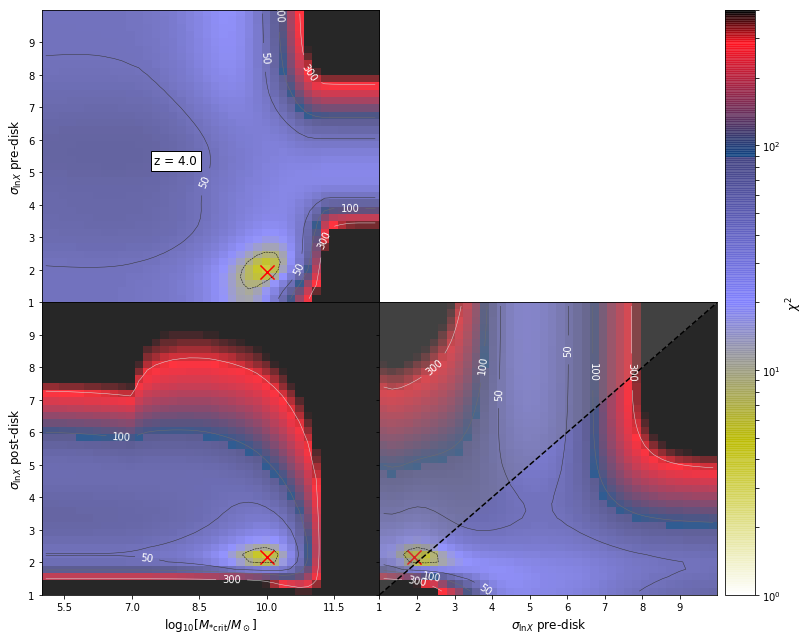

In [24]:
def CHI2_SHEN_sepz(z, pdf, FILE = "output/chi2_3pShenfit_40_nw_mk3.h5py"):
    fig = plt.figure(figsize=(12,9))
    gs = gridspec.GridSpec(2, 2)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()
                     
    axj = [0,0,1]
    axi = [0,1,1]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)


    
    extents = [[logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]],\
               [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]],\
               [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]]]
        
    xlabels = ['', r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$', r'$\sigma_{\ln{X}}$ pre-disk']
    ylabels = [r'$\sigma_{\ln{X}}$ pre-disk', r'$\sigma_{\ln{X}}$ post-disk', '']
    axiss = [(1,2),(0,2),(0,1)]
    sums = [0,1,2]
    axess = [[5,12.5,1.0,10.0],[5,12.5,1.0,10.0],[1.0,10.0,1.0,10.0]]
    vmin = [1,1,1]
    vmax = [400,400,400]
    xticks = [np.linspace(5.5,11.5,5), np.linspace(5.5,11.5,5), [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]]
    yticks = [[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0],[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0],[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]]                     
    for ind, i, j in zip(range(3), axi, axj):
        
        f = h5py.File(FILE, "r")
        file = 'Chi2_SHEN_r40_z'+str(z)
        chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
        f.close()
        
        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)
        print(minval, minind)
        
        bestpost = siglnX2[minind[0][0]]
        bestpre = siglnX1[minind[1][0]]
        bestcrit = logMstar0[minind[2][0]]
        
        print(bestpost, bestpre, bestcrit)
        
        
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        axis = axess[ind]
        extent = extents[ind]

                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel,fontsize=12)
        ax.set_ylabel(ylabel,fontsize=12)
        ax.axis(axis)
        
        plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
        
        if sums[ind] == 1:
            grid2d = chi23d[:,minind[1][0],:]
            ax.scatter(bestcrit, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 2:
            grid2d = chi23d[:,:,minind[2][0]]
            ax.scatter(bestpre, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 0:
            grid2d = chi23d[minind[0][0],:,:]
            ax.scatter(bestcrit, bestpre, marker = 'x', c='r',s=200)
            
#         norm = colors.LogNorm()
#         norm=colors.PowerNorm(gamma=0.4)
#         img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm = norm)
#         cont = ax.contour(grid2d, extent = extent, cmap='binary_r', origin = 'image',linewidths=.5)
#         plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
     
    
        norm = colors.LogNorm()
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, vmin = 1, vmax=400, alpha=0.85)
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,300],cmap='binary_r', vmin = 10, vmax = 400, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220))
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220),linestyles='dashed')
        
    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l).set_label(label=r'$\chi ^2$ ',size=12)
    plt.setp(axes_l[0].get_xticklabels(), visible=False)    
    plt.setp(axes_l[2].get_yticklabels(), visible=False)
    axes_l[0].text(7.5,5.25,'z = '+str(z), bbox=props, fontsize=12)
    axes_l[2].plot(np.linspace(1.0,10.0,2),np.linspace(1.0,10.0,2), linestyle = 'dashed',c='k')
    axes_l[2].fill_between(np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2)+20, color='gray', alpha=.3)
    pdf.savefig(fig)

with PdfPages('plots/Chi2-plots/CHI2_SHEN_r40_allz.pdf') as pdf:  
    for z in [0.0,1.0,2.0,3.0,4.0]:
        CHI2_SHEN_sepz(z=z, pdf=pdf)


In [398]:
def CHI2_SHEN(FILE):
    fig = plt.figure(figsize=(12,9))
    gs = gridspec.GridSpec(2, 2)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()
    
    count = 0
    f = h5py.File(FILE, "r")
    for z in [0.0,1.0,2.0,3.0,4.0]:
        if count == 0:
            chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
        else:
            chi23d += f['z='+str(z)+'/chi23d_grid'][:].T
        count += 1
    f.close()
    chi23d = chi23d/5.0
                     
    axj = [0,0,1]
    axi = [0,1,1]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)


    
    extents = [[logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]],\
               [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]],\
               [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]]]
        
    xlabels = ['', r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$', r'$\sigma_{\ln{X}}$ pre-disk']
    ylabels = [r'$\sigma_{\ln{X}}$ pre-disk', r'$\sigma_{\ln{X}}$ post-disk', '']
    axiss = [(1,2),(0,2),(0,1)]
    sums = [0,1,2]
    axess = [[5,12.5,1.0,10.0],[5,12.5,1.0,10.0],[1.0,10.0,1.0,10.0]]
    vmin = [1,1,1]
    vmax = [400,400,400]
    xticks = [np.linspace(5.5,11.5,5), np.linspace(5.5,11.5,5), [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]]
    yticks = [[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0],[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0],[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]]                     
    for ind, i, j in zip(range(3), axi, axj):
        
        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)
        
        bestpost = siglnX2[minind[0][0]]
        bestpre = siglnX1[minind[1][0]]
        bestcrit = logMstar0[minind[2][0]]
        
        print(bestpost, bestpre, bestcrit)
        
        
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        axis = axess[ind]
        extent = extents[ind]

                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel,fontsize=12)
        ax.set_ylabel(ylabel,fontsize=12)
        ax.axis(axis)
        
        plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
        
        if sums[ind] == 1:
            grid2d = chi23d[:,minind[1][0],:]
            ax.scatter(bestcrit, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 2:
            grid2d = chi23d[:,:,minind[2][0]]
            ax.scatter(bestpre, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 0:
            grid2d = chi23d[minind[0][0],:,:]
            ax.scatter(bestcrit, bestpre, marker = 'x', c='r',s=200)
     
    
        norm = colors.LogNorm()
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, vmin = minval, vmax=400, alpha=0.85)
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,300],cmap='binary_r', vmin = 10, vmax = 400, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220))
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[25],cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220),linestyles='dashed')
        plt.clabel(cont, inline=True, fontsize=10, colors='k', fmt = '%d')
        
    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l).set_label(label=r'$\chi ^2$ ',size=12)
    plt.setp(axes_l[0].get_xticklabels(), visible=False)    
    plt.setp(axes_l[2].get_yticklabels(), visible=False)
    axes_l[0].text(7.5,5.25,'z = '+str(z), bbox=props, fontsize=12)
    axes_l[2].plot(np.linspace(1.0,10.0,2),np.linspace(1.0,10.0,2), linestyle = 'dashed',c='k')
    axes_l[2].fill_between(np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2)+20, color='gray', alpha=.3)
    plt.savefig('plots/Chi2-plots/CHI2_SHEN_r40_stackz.pdf')


CHI2_SHEN("output/chi2_3pShenfit_40_nw_mk3.h5py")


FigureCanvasNbAgg()

1.2307692307692308 4.461538461538462 10.576923076923077
1.2307692307692308 4.461538461538462 10.576923076923077
1.2307692307692308 4.461538461538462 10.576923076923077


AIRD FIT CHI2 GRIDS:

All redshift values for parameters pre-disk sigma, low M* slope, and Mbh norm in a multipage pdf.

In [383]:
def CHI2_SHEN_sepz(z, pdf, FILE = "output/chi2_3pShenfit_30_newparams.h5py"):
    fig = plt.figure(figsize=(12,9))
    gs = gridspec.GridSpec(2, 2)
    
    
    f = h5py.File(FILE, "r")
    slope_low = f['slope_low'][:]
    norm_from_local = f['norm_from_local'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()
                     
    axj = [0,0,1]
    axi = [0,1,1]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)


    
    extents = [[slope_low[0], slope_low[-1], siglnX1[-1], siglnX1[0]],\
               [slope_low[0], slope_low[-1], norm_from_local[-1], norm_from_local[0]],\
               [siglnX1[0], siglnX1[-1], norm_from_local[-1], norm_from_local[0]]]
        
    xlabels = ['', r'pre-disk $\log_{10}[$M$_{\rm{BH}}] / \log_{10}[$M$_{*}]$', r'$\sigma_{\ln{X}}$ pre-disk']
    ylabels = [r'$\sigma_{\ln{X}}$ pre-disk', r'$\log_{10}[$M$_{\rm{BHnorm}}]$', '']
    axiss = [(1,2),(0,2),(0,1)]
    sums = [0,1,2]
    axess = [[0.01,1.5,1,10.0],[0.01,1.5,0,3.0],[1,10.0,0,3.0]]
    xticks = [[0.01, 0.25, 0.5, 0.75, 1.0, 1.25], [0.01, 0.25, 0.5, 0.75, 1.0, 1.25], [2,3,4,5,6,7,8,9,10]]
    yticks = [[2,3,4,5,6,7,8,9,10],[0.25,0.75,1.25, 1.75,2.25, 2.75],[0.25,0.75,1.25, 1.75,2.25, 2.75]]
    
    for ind, i, j in zip(range(3), axi, axj):
        
        f = h5py.File(FILE, "r")
        chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
        f.close()
        
        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)
#         print(minval, minind)
        
        bestnorm = norm_from_local[minind[0][0]]
        bestpre = siglnX1[minind[1][0]]
        bestslope = slope_low[minind[2][0]]
        
        print(bestnorm, bestpre, bestslope)
        
        
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        axis = axess[ind]
        extent = extents[ind]

                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel,fontsize=12)
        ax.set_ylabel(ylabel,fontsize=12)
        ax.axis(axis)
        
        plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
        
        if sums[ind] == 1:
            grid2d = chi23d[:,minind[1][0],:]
            ax.scatter(bestslope, bestnorm, marker = 'x', c='r',s=200)
        elif sums[ind] == 2:
            grid2d = chi23d[:,:,minind[2][0]]
            ax.scatter(bestpre, bestnorm, marker = 'x', c='r',s=200)
        elif sums[ind] == 0:
            grid2d = chi23d[minind[0][0],:,:]

            ax.scatter(bestslope, bestpre, marker = 'x', c='r',s=200)
     
    
        norm = colors.LogNorm()
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, vmin = 10, vmax=400, alpha=0.85)
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,300],cmap='binary_r', vmin = 10, vmax = 400, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220))
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220),linestyles='dashed')
        
    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l).set_label(label=r'$\chi ^2$ ',size=12)
    plt.setp(axes_l[0].get_xticklabels(), visible=False)    
    plt.setp(axes_l[2].get_yticklabels(), visible=False)
    axes_l[0].text(0.5,7,'z = '+str(z), bbox=props, fontsize=12)
    pdf.savefig(fig)

with PdfPages('plots/Chi2-plots/CHI2_SHEN_r30_allz-newparams.pdf') as pdf:  
    for z in [0.0,1.0,2.0,3.0,4.0]:
        CHI2_SHEN_sepz(z=z, pdf=pdf)


FigureCanvasNbAgg()

2.896551724137931 5.344827586206897 0.36965517241379314
2.896551724137931 5.344827586206897 0.36965517241379314
2.896551724137931 5.344827586206897 0.36965517241379314


FigureCanvasNbAgg()

0.20689655172413793 2.5517241379310347 1.5
0.20689655172413793 2.5517241379310347 1.5
0.20689655172413793 2.5517241379310347 1.5


FigureCanvasNbAgg()

1.8620689655172413 3.4827586206896552 0.5237931034482759
1.8620689655172413 3.4827586206896552 0.5237931034482759
1.8620689655172413 3.4827586206896552 0.5237931034482759


FigureCanvasNbAgg()

0.8275862068965517 3.4827586206896552 1.1917241379310346
0.8275862068965517 3.4827586206896552 1.1917241379310346
0.8275862068965517 3.4827586206896552 1.1917241379310346


FigureCanvasNbAgg()

0.3103448275862069 2.8620689655172415 1.5
0.3103448275862069 2.8620689655172415 1.5
0.3103448275862069 2.8620689655172415 1.5


SHEN FIT CHI2 GRIDS:

All redshift values for parameters pre-disk sigma, low M* slope, Mbh norm post-disk sig and M*crit in a multipage pdf.

In [402]:
def CHI2_SHEN_sepz(FILE):
    fig = plt.figure(figsize=(12,9))
    gs = gridspec.GridSpec(2, 2)
    
    
    f = h5py.File(FILE, "r")
    slope_low = f['slope_low'][:]
    norm_from_local = f['norm_from_local'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()
    
    count = 0
    f = h5py.File(FILE, "r")
    for z in [0.0,1.0,2.0,3.0,4.0]:
        if count == 0:
            chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
        else:
            chi23d += f['z='+str(z)+'/chi23d_grid'][:].T
        count += 1
    f.close()
    chi23d = chi23d/5.0
    
    axj = [0,0,1]
    axi = [0,1,1]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)


    
    extents = [[slope_low[0], slope_low[-1], siglnX1[-1], siglnX1[0]],\
               [slope_low[0], slope_low[-1], norm_from_local[-1], norm_from_local[0]],\
               [siglnX1[0], siglnX1[-1], norm_from_local[-1], norm_from_local[0]]]
        
    xlabels = ['', r'pre-disk $\log_{10}[$M$_{\rm{BH}}] / \log_{10}[$M$_{*}]$', r'$\sigma_{\ln{X}}$ pre-disk']
    ylabels = [r'$\sigma_{\ln{X}}$ pre-disk', r'$\log_{10}[$M$_{\rm{BHnorm}}]$', '']
    axiss = [(1,2),(0,2),(0,1)]
    sums = [0,1,2]
    axess = [[0.01,1.5,1,10.0],[0.01,1.5,0,3.0],[1,10.0,0,3.0]]
    xticks = [[0.01, 0.25, 0.5, 0.75, 1.0, 1.25], [0.01, 0.25, 0.5, 0.75, 1.0, 1.25], [2,3,4,5,6,7,8,9,10]]
    yticks = [[2,3,4,5,6,7,8,9,10],[0.25,0.75,1.25, 1.75,2.25, 2.75],[0.25,0.75,1.25, 1.75,2.25, 2.75]]
    
    for ind, i, j in zip(range(3), axi, axj):
        
        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)
        
        bestnorm = norm_from_local[minind[0][0]]
        bestpre = siglnX1[minind[1][0]]
        bestslope = slope_low[minind[2][0]]        
        
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        axis = axess[ind]
        extent = extents[ind]

                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel,fontsize=12)
        ax.set_ylabel(ylabel,fontsize=12)
        ax.axis(axis)
        
        plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
        
        if sums[ind] == 1:
            grid2d = chi23d[:,minind[1][0],:]
            ax.scatter(bestslope, bestnorm, marker = 'x', c='r',s=200)
        elif sums[ind] == 2:
            grid2d = chi23d[:,:,minind[2][0]]
            ax.scatter(bestpre, bestnorm, marker = 'x', c='r',s=200)
        elif sums[ind] == 0:
            grid2d = chi23d[minind[0][0],:,:]
            ax.scatter(bestslope, bestpre, marker = 'x', c='r',s=200)
     
    
        norm = colors.LogNorm()
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, vmin = minval, vmax=200, alpha=0.85)
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,300],cmap='binary_r', vmin = 10, vmax = 400, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220))
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220),linestyles='dashed')
        
    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l).set_label(label=r'$\chi ^2$ ',size=12)
    plt.setp(axes_l[0].get_xticklabels(), visible=False)    
    plt.setp(axes_l[2].get_yticklabels(), visible=False)
    plt.savefig('plots/Chi2-plots/CHI2_SHEN_r30_stackz-newparams_oldset.pdf')


CHI2_SHEN_sepz("output/chi2_3pShenfit_30_newparams_oldset.h5py")


FigureCanvasNbAgg()

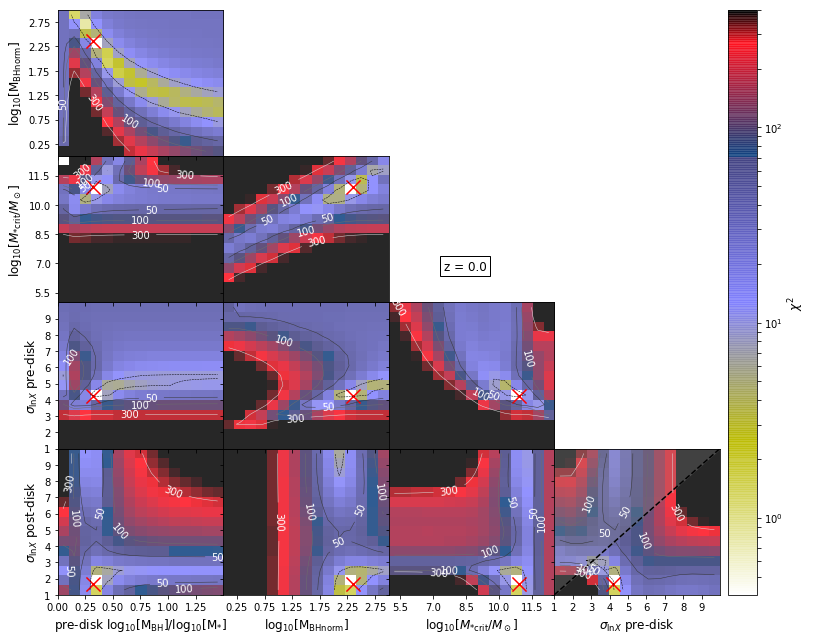

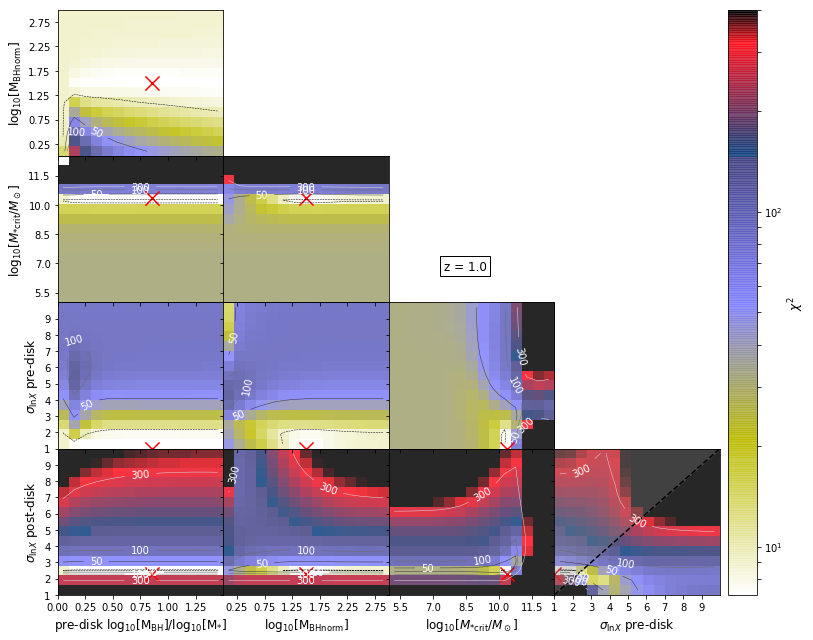

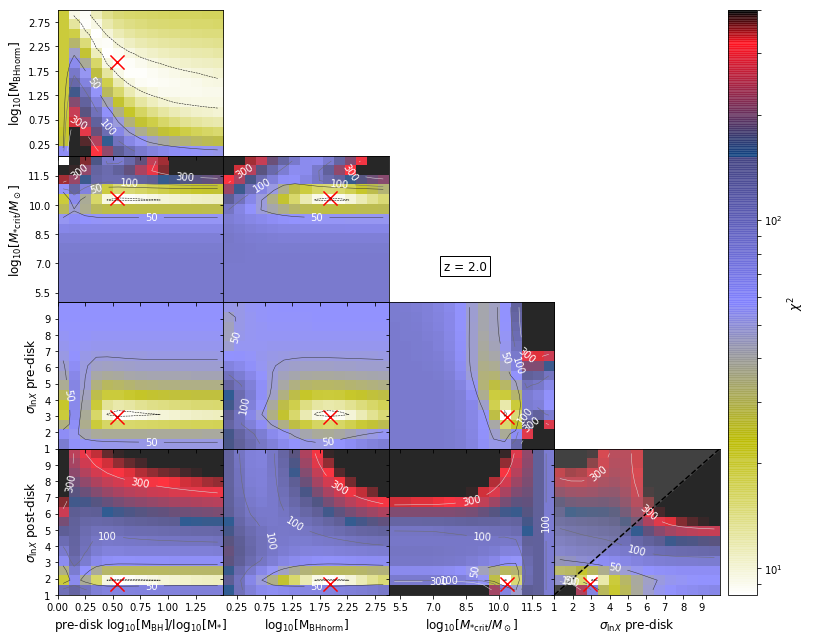

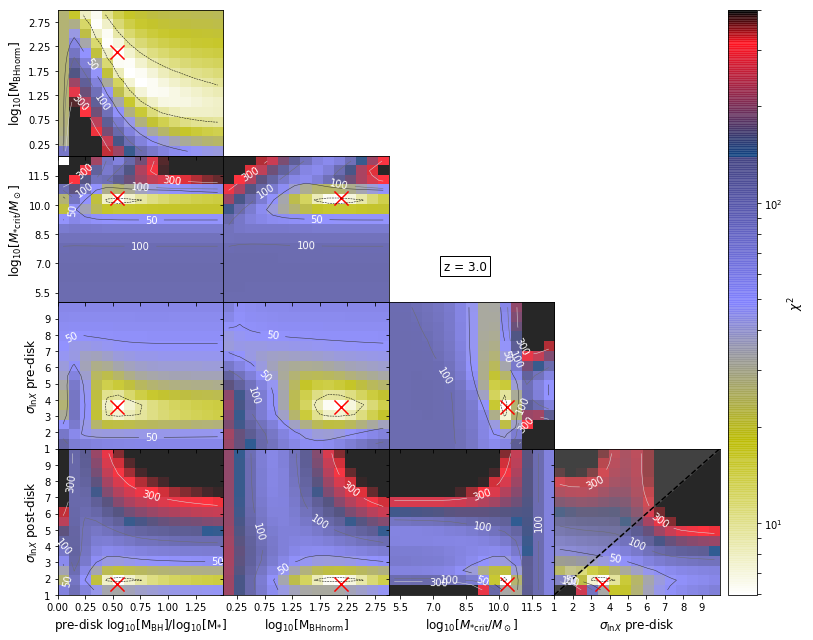

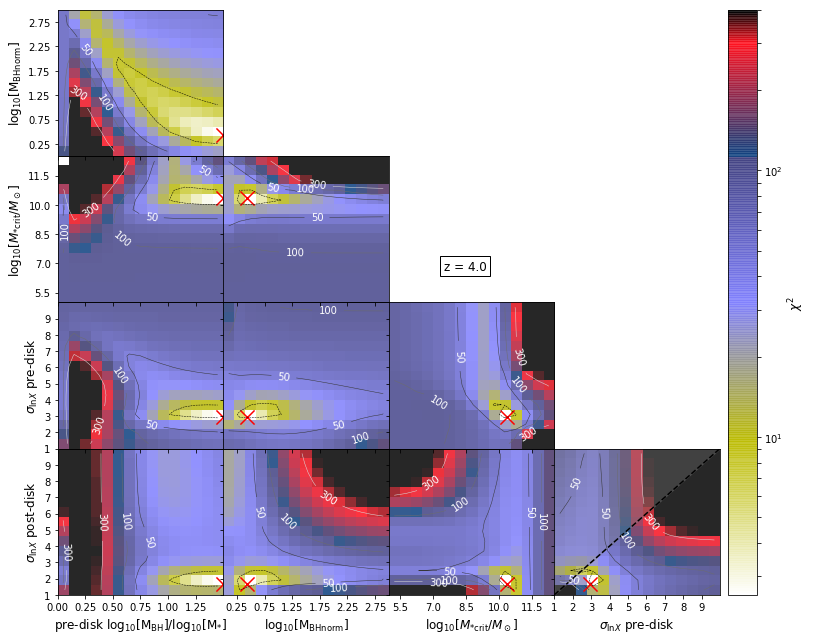

In [67]:
def CHI2_SHEN_sepz_allparam(z, pdf, FILE = "output/chi2_3pShenfit_15_newparams-mk2.h5py"):
    fig = plt.figure(figsize=(12,9))
    gs = gridspec.GridSpec(4, 4)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    slope_low = f['slope_low'][:]
    norm_from_local = f['norm_from_local'][:]
    f.close()
                     
    axj = [0,1,2,3,0,1,2,0,1,0]
    axi = [3,3,3,3,2,2,2,1,1,0]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)


    
    extents = [[slope_low[0], slope_low[-1], siglnX2[-1], siglnX2[0]],\
               [norm_from_local[0], norm_from_local[-1], siglnX2[-1], siglnX2[0]],\
               [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]],\
               [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]],\
               [slope_low[0], slope_low[-1], siglnX1[-1], siglnX1[0]],\
               [norm_from_local[0], norm_from_local[-1], siglnX1[-1], siglnX1[0]],\
               [logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]],\
               [slope_low[0], slope_low[-1], logMstar0[-1], logMstar0[0]],\
               [norm_from_local[0], norm_from_local[-1], logMstar0[-1], logMstar0[0]],\
               [slope_low[0], slope_low[-1], norm_from_local[-1], norm_from_local[0]]]
    
    bl = ''  
    slopel = r'pre-disk $\log_{10}[$M$_{\rm{BH}}] / \log_{10}[$M$_{*}]$'
    norml = r'$\log_{10}[$M$_{\rm{BHnorm}}]$'
    prel = r'$\sigma_{\ln{X}}$ pre-disk'
    postl = r'$\sigma_{\ln{X}}$ post-disk'
    critl = r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$'
    xlabels = [slopel, norml, critl, prel, bl, bl, bl, bl, bl, bl]
    ylabels = [postl, bl, bl, bl, prel, bl, bl, critl, bl, norml]
    axess = [[0,1.5,1,10],[0,3,1,10],[5,12.5,1,10],[1,10,1,10],[0,1.5,1,10],[0,3,1,10],[5,12.5,1,10],[0,1.5,5,12.5],[0,3,5,12.5],[0,1.5,0,3]]
    slopet = [0, 0.25, 0.5, 0.75, 1.0, 1.25]
    normt = [0.25,0.75,1.25, 1.75,2.25, 2.75]
    pret = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
    postt = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
    critt = np.linspace(5.5,11.5,5)
    xticks = [slopet, normt, critt, pret, slopet, normt, critt, slopet, normt, slopet]
    yticks = [postt, postt, postt, postt, pret, pret, pret, critt, critt, normt] 
    sums = [0,1,2,3,4,5,6,7,8,9]
    for ind, i, j in zip(range(10), axi, axj):
        
        f = h5py.File(FILE, "r")
        file = 'Chi2_SHEN_r40_z'+str(z)
        chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
        f.close()
        
        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)
#         print(minval, minind)
        
        bestnorm = norm_from_local[minind[0][0]]
        bestslope = slope_low[minind[1][0]]
        bestpost = siglnX2[minind[2][0]]
        bestpre = siglnX1[minind[3][0]]
        bestcrit = logMstar0[minind[4][0]]
        
#         print(bestpost, bestpre, bestcrit, bestslope, bestnorm)
        
        
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        axis = axess[ind]
        extent = extents[ind]

                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel,fontsize=12)
        ax.set_ylabel(ylabel,fontsize=12)
        ax.axis(axis)
        
        plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
        
        if sums[ind] == 0:
            grid2d = chi23d[minind[0][0],:,:,minind[3][0],minind[4][0]].T
            ax.scatter(bestslope, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 1:
            grid2d = chi23d[:,minind[1][0],:,minind[3][0],minind[4][0]].T          
            ax.scatter(bestnorm, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 2:
            grid2d = chi23d[minind[0][0],minind[1][0],:,minind[3][0],:]           
            ax.scatter(bestcrit, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 3:
            grid2d = chi23d[minind[0][0],minind[1][0],:,:,minind[4][0]]           
            ax.scatter(bestpre, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 4:
            grid2d = chi23d[minind[0][0],:,minind[2][0],:,minind[4][0]].T           
            ax.scatter(bestslope, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 5:
            grid2d = chi23d[:,minind[1][0],minind[2][0],:,minind[4][0]].T            
            ax.scatter(bestnorm, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 6:
            grid2d = chi23d[minind[0][0],minind[1][0],minind[2][0],:,:]           
            ax.scatter(bestcrit, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 7:
            grid2d = chi23d[minind[0][0],:,minind[2][0],minind[3][0],:].T           
            ax.scatter(bestslope, bestcrit, marker = 'x', c='r',s=200)
        elif sums[ind] == 8:
            grid2d = chi23d[:,minind[1][0],minind[2][0],minind[3][0],:].T        
            ax.scatter(bestnorm, bestcrit, marker = 'x', c='r',s=200)
        elif sums[ind] == 9:            
            grid2d = chi23d[:,:,minind[2][0],minind[3][0],minind[4][0]]           
            ax.scatter(bestslope, bestnorm, marker = 'x', c='r',s=200)
     
    
        norm = colors.LogNorm()
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, vmin = minval, vmax=400, alpha=0.85)
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,300],cmap='binary_r', vmin = 10, vmax = 400, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220))
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220),linestyles='dashed')
        
    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l).set_label(label=r'$\chi ^2$ ',size=12)
    plt.setp(axes_l[4].get_xticklabels(), visible=False)
    plt.setp(axes_l[5].get_xticklabels(), visible=False)
    plt.setp(axes_l[6].get_xticklabels(), visible=False)
    plt.setp(axes_l[7].get_xticklabels(), visible=False)
    plt.setp(axes_l[8].get_xticklabels(), visible=False)
    plt.setp(axes_l[9].get_xticklabels(), visible=False)
    plt.setp(axes_l[1].get_yticklabels(), visible=False)
    plt.setp(axes_l[2].get_yticklabels(), visible=False)
    plt.setp(axes_l[3].get_yticklabels(), visible=False)
    plt.setp(axes_l[5].get_yticklabels(), visible=False)
    plt.setp(axes_l[6].get_yticklabels(), visible=False)
    plt.setp(axes_l[8].get_yticklabels(), visible=False)
    axes_l[6].text(7.5,12,'z = '+str(z), bbox=props, fontsize=12)
    axes_l[3].plot(np.linspace(1.0,10.0,2),np.linspace(1.0,10.0,2), linestyle = 'dashed',c='k')
    axes_l[3].fill_between(np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2)+20, color='gray', alpha=.3)
    pdf.savefig(fig)

with PdfPages('plots/Chi2-plots/CHI2_SHEN_r15_allz_allparam.pdf') as pdf:  
    for z in [0.0,1.0,2.0,3.0,4.0]:
        CHI2_SHEN_sepz_allparam(z=z, pdf=pdf)


In [344]:
def CHI2_SHEN_sepz_allparam(FILE):
    fig = plt.figure(figsize=(12,9))
    gs = gridspec.GridSpec(4, 4)
    
    
    count = 0
    f = h5py.File(FILE, "r")
    for z in [0.0,1.0,2.0,3.0,4.0]:
        if count == 0:
            chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
        else:
            chi23d += f['z='+str(z)+'/chi23d_grid'][:].T
        count += 1
    f.close()
    chi23d = chi23d/5.0
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    slope_low = f['slope_low'][:]
    norm_from_local = f['norm_from_local'][:]
    f.close()
                     
    axj = [0,1,2,3,0,1,2,0,1,0]
    axi = [3,3,3,3,2,2,2,1,1,0]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)


    
    extents = [[slope_low[0], slope_low[-1], siglnX2[-1], siglnX2[0]],\
               [norm_from_local[0], norm_from_local[-1], siglnX2[-1], siglnX2[0]],\
               [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]],\
               [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]],\
               [slope_low[0], slope_low[-1], siglnX1[-1], siglnX1[0]],\
               [norm_from_local[0], norm_from_local[-1], siglnX1[-1], siglnX1[0]],\
               [logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]],\
               [slope_low[0], slope_low[-1], logMstar0[-1], logMstar0[0]],\
               [norm_from_local[0], norm_from_local[-1], logMstar0[-1], logMstar0[0]],\
               [slope_low[0], slope_low[-1], norm_from_local[-1], norm_from_local[0]]]
    
    bl = ''  
    slopel = r'pre-disk $\log_{10}[$M$_{\rm{BH}}] / \log_{10}[$M$_{*}]$'
    norml = r'$\log_{10}[$M$_{\rm{BHnorm}}]$'
    prel = r'$\sigma_{\ln{X}}$ pre-disk'
    postl = r'$\sigma_{\ln{X}}$ post-disk'
    critl = r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$'
    xlabels = [slopel, norml, critl, prel, bl, bl, bl, bl, bl, bl]
    ylabels = [postl, bl, bl, bl, prel, bl, bl, critl, bl, norml]
    axess = [[0,1.5,1,10],[0,3,1,10],[5,12.5,1,10],[1,10,1,10],[0,1.5,1,10],[0,3,1,10],[5,12.5,1,10],[0,1.5,5,12.5],[0,3,5,12.5],[0,1.5,0,3]]
    slopet = [0, 0.25, 0.5, 0.75, 1.0, 1.25]
    normt = [0.25,0.75,1.25, 1.75,2.25, 2.75]
    pret = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
    postt = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
    critt = np.linspace(5.5,11.5,5)
    xticks = [slopet, normt, critt, pret, slopet, normt, critt, slopet, normt, slopet]
    yticks = [postt, postt, postt, postt, pret, pret, pret, critt, critt, normt] 
    sums = [0,1,2,3,4,5,6,7,8,9]
    for ind, i, j in zip(range(10), axi, axj):
        
        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)
#         print(minval, minind)
        
        bestnorm = norm_from_local[minind[0][0]]
        bestslope = slope_low[minind[1][0]]
        bestpost = siglnX2[minind[2][0]]
        bestpre = siglnX1[minind[3][0]]
        bestcrit = logMstar0[minind[4][0]]
        
#         print(bestpost, bestpre, bestcrit, bestslope, bestnorm)
        
        
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        axis = axess[ind]
        extent = extents[ind]

                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel,fontsize=12)
        ax.set_ylabel(ylabel,fontsize=12)
        ax.axis(axis)
        
        plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
        
        if sums[ind] == 0:
            grid2d = chi23d[minind[0][0],:,:,minind[3][0],minind[4][0]].T
            ax.scatter(bestslope, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 1:
            grid2d = chi23d[:,minind[1][0],:,minind[3][0],minind[4][0]].T          
            ax.scatter(bestnorm, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 2:
            grid2d = chi23d[minind[0][0],minind[1][0],:,minind[3][0],:]           
            ax.scatter(bestcrit, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 3:
            grid2d = chi23d[minind[0][0],minind[1][0],:,:,minind[4][0]]           
            ax.scatter(bestpre, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 4:
            grid2d = chi23d[minind[0][0],:,minind[2][0],:,minind[4][0]].T           
            ax.scatter(bestslope, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 5:
            grid2d = chi23d[:,minind[1][0],minind[2][0],:,minind[4][0]].T            
            ax.scatter(bestnorm, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 6:
            grid2d = chi23d[minind[0][0],minind[1][0],minind[2][0],:,:]           
            ax.scatter(bestcrit, bestpre, marker = 'x', c='r',s=200)
        elif sums[ind] == 7:
            grid2d = chi23d[minind[0][0],:,minind[2][0],minind[3][0],:].T           
            ax.scatter(bestslope, bestcrit, marker = 'x', c='r',s=200)
        elif sums[ind] == 8:
            grid2d = chi23d[:,minind[1][0],minind[2][0],minind[3][0],:].T        
            ax.scatter(bestnorm, bestcrit, marker = 'x', c='r',s=200)
        elif sums[ind] == 9:            
            grid2d = chi23d[:,:,minind[2][0],minind[3][0],minind[4][0]]           
            ax.scatter(bestslope, bestnorm, marker = 'x', c='r',s=200)
     
    
        norm = colors.LogNorm()
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, vmin = minval, vmax=400, alpha=0.85)
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,300],cmap='binary_r', vmin = 10, vmax = 400, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220))
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220),linestyles='dashed')
        
    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l).set_label(label=r'$\chi ^2$ ',size=12)
    plt.setp(axes_l[4].get_xticklabels(), visible=False)
    plt.setp(axes_l[5].get_xticklabels(), visible=False)
    plt.setp(axes_l[6].get_xticklabels(), visible=False)
    plt.setp(axes_l[7].get_xticklabels(), visible=False)
    plt.setp(axes_l[8].get_xticklabels(), visible=False)
    plt.setp(axes_l[9].get_xticklabels(), visible=False)
    plt.setp(axes_l[1].get_yticklabels(), visible=False)
    plt.setp(axes_l[2].get_yticklabels(), visible=False)
    plt.setp(axes_l[3].get_yticklabels(), visible=False)
    plt.setp(axes_l[5].get_yticklabels(), visible=False)
    plt.setp(axes_l[6].get_yticklabels(), visible=False)
    plt.setp(axes_l[8].get_yticklabels(), visible=False)
    axes_l[3].plot(np.linspace(1.0,10.0,2),np.linspace(1.0,10.0,2), linestyle = 'dashed',c='k')
    axes_l[3].fill_between(np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2), np.linspace(1.0,10.0,2)+20, color='gray', alpha=.3)
 
    plt.savefig('plots/Chi2-plots/CHI2_SHEN_r15_stackz_allparam.pdf')
    
CHI2_SHEN_sepz_allparam("output/chi2_3pShenfit_15_newparams-mk2.h5py")


FigureCanvasNbAgg()

AIRD FIT CHI2 GRIDS:

All redshift values for parameters pre-disk sigma, low M* slope, and Mbh norm.

In [415]:
###### GLOBAL MIN PLOT
from matplotlib import colors


def CHI2_POSTvsCRIT(FILE = "output/chi2_3pARIDfit_15_newparams_wfloor_Shen-set.h5py"):
    fig = plt.figure(figsize=(12,9))
    gs = gridspec.GridSpec(2, 2)
    
    
    f = h5py.File(FILE, "r")
    slope_low = f['slope_low'][:]
    norm_from_local = f['norm_from_local'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()
                   
    axj = [0,0,1]
    axi = [0,1,1]
    axes_l = []
    
    extents = [[slope_low[0], slope_low[-1], siglnX1[-1], siglnX1[0]],\
               [slope_low[0], slope_low[-1], norm_from_local[-1], norm_from_local[0]],\
               [siglnX1[0], siglnX1[-1], norm_from_local[-1], norm_from_local[0]]]
        
    xlabels = ['', r'pre-disk $\log_{10}[$M$_{\rm{BH}}] / \log_{10}[$M$_{*}]$', r'$\sigma_{\ln{X}}$ pre-disk']
    ylabels = [r'$\sigma_{\ln{X}}$ pre-disk', r'$\log_{10}[$M$_{\rm{BHnorm}}]$', '']
    axiss = [(1,2),(0,2),(0,1)]
    sums = [0,1,2]
    axess = [[0.01,1.5,1,10.0],[0.01,1.5,0,3.0],[1,10.0,0,3.0]]
    xticks = [[0.01, 0.25, 0.5, 0.75, 1.0, 1.25], [0.01, 0.25, 0.5, 0.75, 1.0, 1.25], [2,3,4,5,6,7,8,9,10]]
    yticks = [[2,3,4,5,6,7,8,9,10],[0.25,0.75,1.25, 1.75,2.25, 2.75],[0.25,0.75,1.25, 1.75,2.25, 2.75]]

                     
    for ind, i, j in zip(range(3), axi, axj):
        f = h5py.File(FILE, "r")
        chi23d = f['chi23d_grid'][:].T
        f.close()
        
        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)
        print(minval, minind)
        
        bestnorm = norm_from_local[minind[0][0]]
        bestpre = siglnX1[minind[1][0]]
        bestslope = slope_low[minind[2][0]]
        
        print(bestnorm, bestpre, bestslope)
                     
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        axis = axess[ind]
        extent = extents[ind]
                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel,fontsize=14)
        ax.set_ylabel(ylabel,fontsize=14)
        ax.axis(axis)
        ax.tick_params(axis='both', which='both', labelsize=13, direction='in')

        
        plt.setp(ax, xticks=xticks[ind],
        yticks=yticks[ind])
        
        if sums[ind] == 1:
            grid2d = chi23d[:,minind[1][0],:]
            ax.scatter(bestslope, bestnorm, marker = 'x', c='r',s=200)
        elif sums[ind] == 2:
            grid2d = chi23d[:,:,minind[2][0]]
            ax.scatter(bestpre, bestnorm, marker = 'x', c='r',s=200)
        elif sums[ind] == 0:
            grid2d = chi23d[minind[0][0],:,:]

            ax.scatter(bestslope, bestpre, marker = 'x', c='r',s=200)
            
        norm = colors.LogNorm()
        norm=colors.PowerNorm(gamma=0.4)
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm = norm, vmin = minval, vmax = 700)

        cont = ax.contour(grid2d, extent = extent, cmap='binary_r', origin = 'image',linewidths=.5)#, levels = [550,700,1000,1300])
        plt.clabel(cont, inline=True, fontsize=11, colors='w', fmt = '%d')
       
    plt.suptitle('Aird et al. (2018) FITS', fontsize = 15)
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l)#, ticks = [525,550,600,700,825,1000,1200,1400])
    cbar.set_label(label=r'$\chi ^2$ ',size=16)
    cbar.ax.tick_params(labelsize=12)
    plt.setp(axes_l[0].get_xticklabels(), visible=False)    
    plt.setp(axes_l[2].get_yticklabels(), visible=False) 


    plt.savefig('plots/Chi2-plots/CHI2_AIRD_r15_wfloor_Shen-set.pdf')

    

CHI2_POSTvsCRIT()


FigureCanvasNbAgg()

272.7837693927202 (array([4]), array([5]), array([10]))
0.8571428571428571 4.214285714285714 1.0742857142857143
272.7837693927202 (array([4]), array([5]), array([10]))
0.8571428571428571 4.214285714285714 1.0742857142857143
272.7837693927202 (array([4]), array([5]), array([10]))
0.8571428571428571 4.214285714285714 1.0742857142857143


In [356]:
def plot_DUTY_sBHAR(ax1, ax2, crit, xsig1, xsig2, slope, norm):
    
    color_list = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
    labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']

    ##collect and plot Aird data
    duty_arid = open("plot_data/fduty_vs_z.dat",'r')
    all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []

    for i in duty_arid.readlines():
        s = i.split()
        if s[0] == 'All':
            zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
            per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
        

    yerr = np.zeros([2,len(el)])
    yerr[0,:], yerr[1,:] = el, eh

    mass = [8.5,9.0,9.5,10.0,10.5,11.0]
    ztot = sorted(set((np.array(zl) + np.array(zh))/2))

    for i, c, l in zip(mass, color_list, labels):
        ind = np.where(np.array(ml) == i)[0]
        z = (np.array(zl)[ind]+np.array(zh)[ind])/2
        dut = np.array(per)[ind]
        err = np.array(yerr)[:,ind]

        ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)


    for c in ['teal', 'gold', 'brown', 'r']:
        x = []
        y = []
        yerrup = []
        yerrdown = []
        duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
        for i in duty_arid.readlines():
            s = i.split()
            if s[0][0] != '#' and s[0] == c:
                x.append(float(s[1]))
                y.append(float(s[2]))
                yerrup.append(float(s[3])-float(s[2]))
                yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
        yerr = np.zeros([2,len(yerrup)])
        yerr[0,:] = yerrdown
        yerr[1,:] = yerrup
        duty_arid.close()

        ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c) 
        
    ### begin plotting our prediction
    L = np.linspace(5,18,200) #log10 of solar luminosities

    count = 0

    DUTY_tot = np.zeros((len(mass),len(ztot)))
    aveETA_tot = np.zeros((len(mass)-2, len(ztot)))

    def dut_eta(Ms, ind):
        MU_lnlambda = MU_lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
        lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms))

        y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
        duty = np.trapz(y[np.e**lnlambda>=0.01]*dNdlnMstar[ind], x=lnlambda[np.e**lnlambda>=0.01])
        aveeta = np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0])*dNdlnMstar[ind])

        return duty, aveeta

    zcount = 0
    for z in ztot:
        qlf = QLF(z, 0.005)
        qlf.get_dNdlnMstar(0.7)
        qlf.get_Mbh(crit, slope, norm, approx_local=False)
        qlf.get_dNdlnL(L, [xsig1,xsig2])

        MdotBH = qlf.MdotBH
        MU_MdotBH = qlf.Mdot_mu_sig[:,0]
        SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
        lnMs = qlf.StellBins
        dNdlnMstar = qlf.dNdlnMstar

        lnLbol = np.log(10**L*3.83e33) #log of erg/s
        MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s

        Mcount = 0
        for Ms in mass:
            inds = np.where((lnMs > Ms) & (lnMs < Ms+0.5))[0]
            lnMstar_tot = np.trapz(dNdlnMstar[inds], x=lnMs[inds])
            h = (lnMs[inds[-1]] - lnMs[inds[0]]) / len(inds)
            for i in inds:
                dut, eta = dut_eta(lnMs[i], i)
                DUTY_tot[Mcount,zcount] += dut*h
                if Mcount >= 2:
                    aveETA_tot[Mcount-2,zcount] += eta*h
            if Mcount >= 2:
                aveETA_tot[Mcount-2,zcount] = aveETA_tot[Mcount-2,zcount]/DUTY_tot[Mcount,zcount]
            DUTY_tot[Mcount,zcount] = DUTY_tot[Mcount,zcount]/lnMstar_tot
            Mcount += 1
        zcount += 1

    pcount = 0
    for i, c in zip(range(0,len(mass)), color_list):
        ax1.plot(ztot, DUTY_tot[i,:]*100, c=c)
        if pcount >= 2:
            if pcount == 2:
                ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c='k')
            ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c=c)
        pcount+=1 
    
    

    ax1.set_yscale('log')
    ax1.set_xlim([0, 4])
    ax1.set_ylim([0.01, 100])
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax1.set_xlabel('Redshift (z)',fontsize=18)
    ax1.set_ylabel('Duty Cycle % f$(\lambda_{sBHAR} > 0.01)$',fontsize=18)
    ax1.legend(loc='lower right',fontsize = 14)
    ax1.tick_params(axis='both', which='both', direction='in', labelsize = 18)


    ax2.set_xlabel('Redshift (z)',fontsize=18)
    ax2.tick_params(axis='both', which='both', direction='in', labelsize = 18)

    ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)
    ax2.set_ylim([-2,0.5])
    
def plot_QLF(ax, color, z, crit, xsig1, xsig2, slope, norm):
    lums = np.linspace(5,18,200)
    lumsshen = np.linspace(8.95,14.95,200)
    lumsp = 10**lums*3.8e33
    lumss = 10**lumsshen*3.8e33
    
    qlf = QLF(z, 0.005)
    qlf.get_dNdlnMstar(0.7)
    qlf.get_Mbh(crit, slope, norm, approx_local=True)
    qlf.get_dNdlnL(lums, [xsig1, xsig2])
    xm, ym = lumsp, np.log10(qlf.dNdlnL * np.log(10))

    
    ax.plot(xm, ym, c=color,lw=2, ls='solid', label='z = '+str(z))
    
    dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen)
    ax.plot(lumss, dens, c=color, linestyle='dashed',lw = 2)
    ax.fill_between(lumss, dens-stanab, dens+stanb, color=color, alpha=.3)
    
    ax.legend(fontsize=14)
    ax.set_xlabel(r'$\log_{10} [L_{bol}]$ (ergs $s^{-1}$)', fontsize=18)
    ax.axis([min(xm),max(xm),-11,-2])
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='both', direction='in', labelsize = 18)
    ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =18)


def plot_SMBM(ax, crit, xsig1, xsig2, slope, norm):
    lums = np.linspace(5,18,200)
    qlf = QLF(1.0, 0.005)
    qlf.get_dNdlnMstar(0.7)
    qlf.get_Mbh(crit, slope, norm, approx_local=True)
    qlf.get_dNdlnL(lums, [xsig1, xsig2])
    Mbh = qlf.BHBins
    Mstar = qlf.StellBins
    ax.plot(Mstar, Mbh, color='k',label='This Model')
    
    ax.plot(Mstar, Mstar-2.8,c='k',linestyle='dotted',label='Local Scaling Relation')
    ax.set_xlabel('$\log[M_*/M_\odot]$',fontsize=18)
    ax.set_ylabel('$\log[M_{BH}/M_\odot]$',fontsize=18)
    ax.set_xlim([7,12.2])
    ax.tick_params(axis='both', which='both', direction='in', labelsize = 18)
    ax.legend(fontsize=14)

In [418]:
fig, (ax1,ax2,ax3,ax4) = plt.subplots(1,4,figsize=(35,8))

f = h5py.File("output/chi2_3pARIDfit_15_newparams_wfloor_Shen-set.h5py", "r")
siglnX1 = f['siglnX1'][:]
slope_low = f['slope_low'][:]
norm_from_local = f['norm_from_local'][:]
chi23d = f['chi23d_grid'][:].T
f.close()

# count = 0
# f = h5py.File("output/chi2_3pShenfit_15_newparams-mk2.h5py", "r")
# logMstar0 = f['logMstar0'][:]
# siglnX2 = f['siglnX2'][:]
# siglnX1 = f['siglnX1'][:]
# slope_low = f['slope_low'][:]
# norm_from_local = f['norm_from_local'][:]
# for z in [0.0,1.0,2.0,3.0,4.0]:
#     if count == 0:
#         chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
#     else:
#         chi23d += f['z='+str(z)+'/chi23d_grid'][:].T
#     count += 1
# f.close()
# minval = np.amin(chi23d)
# minind = np.where(chi23d == minval)
# bestnorm = norm_from_local[minind[0][0]]
# bestslope = slope_low[minind[1][0]]
# siglnX2 = siglnX2[minind[2][0]]
# bestpre = siglnX1[minind[3][0]]
# logMstar0 = logMstar0[minind[4][0]]
 
        
logMstar0 = 10.36
siglnX2 = 1.64

minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestnorm = norm_from_local[minind[0][0]]
bestpre = siglnX1[minind[1][0]]
bestslope = slope_low[minind[2][0]]

print('Norm =', bestnorm, 'Pre-disk sig =', bestpre, 'low-mass slope =', bestslope, 'Mstarcrit =', logMstar0, 'Post-dusk sig =',siglnX2)
                                      
params = {'crit':logMstar0, 'xsig1':bestpre, 'xsig2':siglnX2, 'slope':bestslope, 'norm':bestnorm}
plot_DUTY_sBHAR(ax1, ax2, **params)
for z, color in zip([0.0,2.0,4.0],['r','orange','yellow','green','b']):
    plot_QLF(ax3, color = color, z = z, **params)
plot_SMBM(ax4, **params)

plt.savefig('plots/Chi2-plots/best_fit_preview_wfloor_Shen-set.pdf')


FigureCanvasNbAgg()

Norm = 0.8571428571428571 Pre-disk sig = 4.214285714285714 low-mass slope = 1.0742857142857143 Mstarcrit = 10.36 Post-dusk sig = 1.64


In [406]:
'''
Aird fits NW: "output/chi2_3pARIDfit_30_newparams_NW.h5py"
Shen fits just old: "output/chi2_3pShenfit_40_nw_mk3.h5py"
Shen fits just new: "output/chi2_3pShenfit_15_newparams.h5py"
Shen fits both: "output/chi2_3pShenfit_15_newparams-mk2.h5py"

'''

NA = '   NA'

#### Aird fits NW
f = h5py.File("output/chi2_3pARIDfit_30_newparams-fixweights_wfloor.h5py", "r")
siglnX1 = f['siglnX1'][:]
slope_low = f['slope_low'][:]
norm_from_local = f['norm_from_local'][:]
chi23d = f['chi23d_grid'][:].T
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestnorm_A = norm_from_local[minind[0][0]]
bestpre_A = siglnX1[minind[1][0]]
bestslope_A = slope_low[minind[2][0]]

print('\nAird best fits:')
print(f'Best crit = {NA},  Best pre-disk = {bestpre_A:.2f}, Best post-disk = {NA},  Best slope = {bestslope_A:.2f}, Best norm = {bestnorm_A:.2f}\n ')

#### loop through Shen fits to get all redshift values

bestpost_SO = []
bestpre_SO = []
bestcrit_SO = []
bestnorm_SN = []
bestpre_SN = []
bestslope_SN = []
bestnorm_SA = []
bestslope_SA = []
bestpost_SA = []
bestpre_SA = []
bestcrit_SA = []

for z in [0.0, 1.0, 2.0, 3.0, 4.0]:
    
    #### Shen fits old params
    f = h5py.File("output/chi2_3pShenfit_40_nw_mk3.h5py", "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
    f.close()
    minval = np.amin(chi23d)
    minind = np.where(chi23d == minval)
    bestpost_SO.append(siglnX2[minind[0][0]])
    bestpre_SO.append(siglnX1[minind[1][0]])
    bestcrit_SO.append(logMstar0[minind[2][0]])

    #### Shen fits new params
    f = h5py.File("output/chi2_3pShenfit_30_newparams_oldset.h5py", "r")
    siglnX1 = f['siglnX1'][:]
    slope_low = f['slope_low'][:]
    norm_from_local = f['norm_from_local'][:]
    chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
    f.close()
    minval = np.amin(chi23d)
    minind = np.where(chi23d == minval)
    bestnorm_SN.append(norm_from_local[minind[0][0]])
    bestpre_SN.append(siglnX1[minind[1][0]])
    bestslope_SN.append(slope_low[minind[2][0]])

    #### Shen fits all params
    f = h5py.File("output/chi2_3pShenfit_15_newparams-mk2.h5py", "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    slope_low = f['slope_low'][:]
    norm_from_local = f['norm_from_local'][:]
    chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
    f.close()
    minval = np.amin(chi23d)
    minind = np.where(chi23d == minval)
    bestnorm_SA.append(norm_from_local[minind[0][0]])
    bestslope_SA.append(slope_low[minind[1][0]])
    bestpost_SA.append(siglnX2[minind[2][0]])
    bestpre_SA.append(siglnX1[minind[3][0]])
    bestcrit_SA.append(logMstar0[minind[4][0]])
 
#### Shen fits old params stacked z
f = h5py.File("output/chi2_3pShenfit_40_nw_mk3.h5py", "r")
count = 0
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
for z in [0.0,1.0,2.0,3.0,4.0]:
    if count == 0:
        chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
    else:
        chi23d += f['z='+str(z)+'/chi23d_grid'][:].T
    count += 1
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestpost_SOS = siglnX2[minind[0][0]]
bestpre_SOS = siglnX1[minind[1][0]]
bestcrit_SOS = logMstar0[minind[2][0]]

print('\nShen best fits (orig, stacked z):')
print(f'Best crit = {bestcrit_SOS:.2f},  Best pre-disk = {bestpre_SOS:.2f}, Best post-disk = {bestpost_SOS:.2f},  Best slope = {NA},  Best norm = {NA}\n ')


####Shen fits new params stacked z
f = h5py.File("output/chi2_3pShenfit_30_newparams_oldset.h5py", "r")
count = 0
siglnX1 = f['siglnX1'][:]
slope_low = f['slope_low'][:]
norm_from_local = f['norm_from_local'][:]
for z in [0.0,1.0,2.0,3.0,4.0]:
    if count == 0:
        chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
    else:
        chi23d += f['z='+str(z)+'/chi23d_grid'][:].T
    count += 1
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestnorm_SNS = norm_from_local[minind[0][0]]
bestslope_SNS = slope_low[minind[2][0]]
bestpre_SNS = siglnX1[minind[1][0]]

print('\nShen best fits (new, stacked z):')
print(f'Best crit = {NA},  Best pre-disk = {bestpre_SNS:.2f}, Best post-disk = {NA},  Best slope = {bestslope_SNS:.2f},  Best norm = {bestnorm_SNS:.2f}\n ')



#### Shen fits all params stacked z
count = 0
f = h5py.File("output/chi2_3pShenfit_15_newparams-mk2.h5py", "r")
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
slope_low = f['slope_low'][:]
norm_from_local = f['norm_from_local'][:]
for z in [0.0,1.0,2.0,3.0,4.0]:
    if count == 0:
        chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
    else:
        chi23d += f['z='+str(z)+'/chi23d_grid'][:].T
    count += 1
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestnorm_SAS = norm_from_local[minind[0][0]]
bestslope_SAS = slope_low[minind[1][0]]
bestpost_SAS = siglnX2[minind[2][0]]
bestpre_SAS = siglnX1[minind[3][0]]
bestcrit_SAS = logMstar0[minind[4][0]]

print('\nShen best fits (all, stacked z):')
print(f'Best crit = {bestcrit_SAS:.2f},  Best pre-disk = {bestpre_SAS:.2f}, Best post-disk = {bestpost_SAS:.2f},  Best slope = {bestslope_SAS:.2f},  Best norm = {bestnorm_SAS:.2f}\n\n ')




Aird best fits:
Best crit =    NA,  Best pre-disk = 4.41, Best post-disk =    NA,  Best slope = 0.98, Best norm = 0.93
 

Shen best fits (orig, stacked z):
Best crit = 10.58,  Best pre-disk = 4.46, Best post-disk = 1.23,  Best slope =    NA,  Best norm =    NA
 

Shen best fits (new, stacked z):
Best crit =    NA,  Best pre-disk = 8.76, Best post-disk =    NA,  Best slope = 0.88,  Best norm = 0.00
 

Shen best fits (all, stacked z):
Best crit = 10.36,  Best pre-disk = 3.57, Best post-disk = 1.64,  Best slope = 0.86,  Best norm = 1.07

 


In [414]:
def setup(ax):
    ax.spines['right'].set_color('none')
    ax.spines['left'].set_color('none')
    ax.yaxis.set_major_locator(ticker.NullLocator())
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.tick_params(which='major', width=1.00)
    ax.tick_params(which='major', length=5)
    ax.tick_params(which='minor', width=0.75)
    ax.tick_params(which='minor', length=2.5)
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 1)
    ax.patch.set_alpha(0.0)


#### for different zs we have different markers
markers = ['$\circ$', '$+$', '$\ominus$', 'x', '$\diamond$']
#### for different variations on fits we have different colors
color_list = ['r', 'purple', 'b', 'k']
size = 100  

method = 'stack' # or 'mean' or 'all'
    
    
fig = plt.figure(figsize=(5, 6))
    
    ##### Mstar CRIT
ax = plt.subplot(5, 1, 1)
setup(ax)
ax.set_xlim(10**5, 10**12)
ax.set_xscale('log')
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=15))
ax.text(0.0, 0.5, r'$\rmM_{*\rm{crit}}(\rmM_\odot)$', fontsize=15, transform=ax.transAxes)
ax.tick_params(axis='both', which='both', direction='in')

##uncomment for individual redshifts
if method == 'all':
    s2 = []
    for p, m in zip(bestcrit_SO, markers):
        ax.scatter(10**p, 0.1, color = color_list[1], marker=m, alpha=0.5, s=size)
    for p, m, z in zip(bestcrit_SA, markers, [0, 1, 2, 3, 4]):
        s1 = ax.scatter(10**p, 0.1, color = color_list[3], marker=m, alpha=0.5, s=size, label='z = '+str(z))
        s2.append(s1)

##uncomment for average redshifts
if method == 'mean':
    ax.scatter(np.mean(10**np.asarray(bestcrit_SO)), 0.1, color = color_list[1], marker='.', alpha=0.5, s=size)
    ax.scatter(np.mean(10**np.asarray(bestcrit_SA)), 0.1, color = color_list[3], marker='.', alpha=0.5, s=size)

###uncomment for stacked redshifts
if method == 'stack':
    ax.scatter(10**bestcrit_SOS, 0.1, color = color_list[1], marker='.', alpha=0.5, s=size)
    ax.scatter(10**bestcrit_SAS, 0.1, color = color_list[3], marker='.', alpha=0.5, s=size)


ax.errorbar(10**10,0,xerr=np.asarray([[10**10-10**9.5],[10**11.5-10**10]]), c='g', elinewidth = 7, capthick = 4, capsize = 7, alpha=0.5)
ax.plot([10**10.3,10**10.3],[0,0.2], c='b')
ax.plot([10**10.3,10**10.3],[0.2,0.35], c='r')



    ##### Pre-disk SIGMA
ax = plt.subplot(5, 1, 2)
setup(ax)
ax.set_xlim(1, 10)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax.text(0.0, 0.5, r'Pre-disk $\sigma_{\ln{\rmX}}$', fontsize=15, transform=ax.transAxes)
ax.tick_params(axis='both', which='both', direction='in')

s3 = ax.scatter(bestpre_A, 0.1, color = color_list[1], marker='.', s=size, label='Shen fit (orig)')
s4 = ax.scatter(bestpre_A, 0.1, color = color_list[2], marker='.', s=size, label='Shen fit (new)')
s5 = ax.scatter(bestpre_A, 0.1, color = color_list[3], marker='.', s=size, label='Shen fit (all)')
s1 = ax.scatter(bestpre_A, 0.1, color = color_list[0], marker='.', s=size, label='Aird II fit')

##uncomment for individual redshifts
if method == 'all':
    for p, m in zip(bestpre_SO, markers):
        ax.scatter(p, 0.1, color = color_list[1], marker=m, alpha=0.5, s=size)
    for p, m in zip(bestpre_SN, markers):
        ax.scatter(p, 0.1, color = color_list[2], marker=m, alpha=0.5, s=size)
    for p, m in zip(bestpre_SA, markers):
        ax.scatter(p, 0.1, color = color_list[3], marker=m, alpha=0.5, s=size)

##uncomment for average redshifts
if method == 'mean':
    ax.scatter(np.mean(bestpre_SO), 0.1, color = color_list[1], marker='.', alpha=0.5, s=size)
    ax.scatter(np.mean(bestpre_SN), 0.1, color = color_list[2], marker='.', alpha=0.5, s=size)
    ax.scatter(np.mean(bestpre_SA), 0.1, color = color_list[3], marker='.', alpha=0.5, s=size)

##uncomment for stacked redshifts
if method == 'stack':
    ax.scatter(bestpre_SOS, 0.1, color = color_list[1], marker='.', alpha=0.5, s=size)
    ax.scatter(bestpre_SNS, 0.1, color = color_list[2], marker='.', alpha=0.5, s=size)
    ax.scatter(bestpre_SAS, 0.1, color = color_list[3], marker='.', alpha=0.5, s=size)

ax.errorbar(6,0,xerr=np.asarray([[3.5],[4]]), c='g', elinewidth = 7, capthick = 4, capsize = 7, alpha=0.5)



    ###### Post-disk SIGMA
ax = plt.subplot(5, 1, 3)
setup(ax)
ax.set_xlim(1, 10)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax.text(0.0, 0.5, r'Post-disk $\sigma_{\ln{\rmX}}$', fontsize=15, transform=ax.transAxes)
ax.tick_params(axis='both', which='both', direction='in')

##uncomment for individual redshifts
if method == 'all':
    for p, m in zip(bestpost_SO, markers):
        ax.scatter(p, 0.1, color = color_list[1], marker=m, alpha=0.5, s=size)
    for p, m in zip(bestpost_SA, markers):
        ax.scatter(p, 0.1, color = color_list[3], marker=m, alpha=0.5, s=size)

# ##uncomment for average redshifts
if method == 'mean':
    ax.scatter(np.mean(bestpost_SO), 0.1, color = color_list[1], marker='.', alpha=0.5, s=size)
    ax.scatter(np.mean(bestpost_SA), 0.1, color = color_list[3], marker='.', alpha=0.5, s=size)

##uncomment for stacked redshifts
if method == 'stack':
    ax.scatter(bestpost_SOS, 0.1, color = color_list[1], marker='.', alpha=0.5, s=size)
    ax.scatter(bestpost_SAS, 0.1, color = color_list[3], marker='.', alpha=0.5, s=size)

ax.errorbar(2,0,xerr=np.asarray([[1],[.5]]), c='g', elinewidth = 7, capthick = 4, capsize = 7, alpha=0.5)
l1 = ax.plot([2.3,2.3],[0,0.2], c='k', label = 'set in fit')
ax.plot([2.3,2.3],[0,0.2], c='b')
ax.plot([2.3,2.3],[0.2,0.35], c='r')




    ##### Slope value
ax = plt.subplot(5, 1, 4)
setup(ax)
ax.set_xlim(0, 1.5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax.text(0.0, 0.5, r'Pre-disk $\ln\rmM_{\rm{BH}}/\ln\rmM_{*}$', fontsize=15, transform=ax.transAxes)
ax.tick_params(axis='both', which='both', direction='in')

ax.scatter(bestslope_A, 0.1, color = color_list[0], marker='.', s=size)

##uncomment for individual redshifts
if method == 'all':
    for p, m in zip(bestslope_SN, markers):
        ax.scatter(p, 0.1, color = color_list[2], marker=m, alpha=0.5, s=size)
    for p, m in zip(bestslope_SA, markers):
        ax.scatter(p, 0.1, color = color_list[3], marker=m, alpha=0.5, s=size)

##uncomment for average redshifts
if method == 'mean':
    ax.scatter(np.mean(bestslope_SN), 0.1, color = color_list[2], marker='.', alpha=0.5, s=size)
    ax.scatter(np.mean(bestslope_SA), 0.1, color = color_list[3], marker='.', alpha=0.5, s=size)

##uncomment for stacked redshifts
if method == 'stack':
    ax.scatter(bestslope_SNS, 0.1, color = color_list[2], marker='.', alpha=0.5, s=size)
    ax.scatter(bestslope_SAS, 0.1, color = color_list[3], marker='.', alpha=0.5, s=size)


ax.errorbar(0.5,0,xerr=np.asarray([[0.5],[0.5]]), c='g', elinewidth = 7, capthick = 4, capsize = 7, alpha=0.5)





    #### Mbh NORM
ax = plt.subplot(5, 1, 5)
setup(ax)
ax.set_xlim(1, 10**3)
ax.set_xscale('log')
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=15))
ax.text(0.0, 0.5, r'M$_{\rm{BHnorm}}(\rmM_\odot)$', fontsize=15, transform=ax.transAxes)
ax.tick_params(axis='both', which='both', direction='in')

ax.scatter(10**bestnorm_A, 0.1, color = color_list[0], marker='.', s=size)
# ##uncomment for individual redshifts
if method == 'all':
    for p, m in zip(bestnorm_SN, markers):
        ax.scatter(10**p, 0.1, color = color_list[2], marker=m, alpha=0.5, s=size)
    for p, m in zip(bestnorm_SA, markers):
        ax.scatter(10**p, 0.1, color = color_list[3], marker=m, alpha=0.5, s=size)
    
##uncomment for average redshifts
if method == 'mean':
    ax.scatter(np.mean(10**np.asarray(bestnorm_SN)), 0.1, color = color_list[2], marker='.', alpha=0.5, s=size)
    ax.scatter(np.mean(10**np.asarray(bestnorm_SA)), 0.1, color = color_list[3], marker='.', alpha=0.5, s=size)

### uncomment for stacked redshifts
if method == 'stack':
    ax.scatter(10**bestnorm_SNS, 0.1, color = color_list[2], marker='.', alpha=0.5, s=size)
    ax.scatter(10**bestnorm_SAS, 0.1, color = color_list[3], marker='.', alpha=0.5, s=size)
    
    
    
    
#### set up the legend
# # uncomment for individual redshifts
if method == 'all':
    fig.legend((s2[0], s2[1], s2[2], s2[3], s2[4]), ('z = 0', 'z = 1', 'z = 2', 'z = 3', 'z = 4'), 'upper right')
    fig.legend((s1, s3, s4, s5, l1), ('Aird II fits', 'Shen fit (orig)', 'Shen fit (new)', 'Shen fit (all)', 'set in fit'), 'upper center')
    plt.savefig('plots/Chi2-plots/best_fit_params.pdf')

## uncomment for mean redshift
if method == 'mean':
    fig.legend((s1, s3, s4, s5, l1), ('Aird II fits', 'Shen fit (orig)', 'Shen fit (new)', 'Shen fit (all)', 'set in fit'), 'upper right')
    plt.savefig('plots/Chi2-plots/best_fit_params_meanz.pdf')

if method == 'stack':
    fig.legend((s1, s3, s4, s5, l1), ('Aird II fits', 'Shen fit (orig)', 'Shen fit (new)', 'Shen fit (all)', 'set in fit'), 'upper right')
    plt.savefig('plots/Chi2-plots/best_fit_params_stackz_oldset.pdf')

FigureCanvasNbAgg()

In [290]:
fig = plt.figure(figsize=(12,9))
gs = gridspec.GridSpec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

#### this collects the arid duty data
duty_arid = open("plot_data/fduty_vs_z.dat",'r')
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []
### read through file
for i in duty_arid.readlines():
    s = i.split()
    if s[0] == 'All':
        zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
        per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
### collect the error values
yerr = np.zeros([2,len(el)])
yerr[0,:], yerr[1,:] = el, eh
### set up mass bins and list of z values to evaluate
mass = [8.5,9.0,9.5,10.0,10.5,11.0]
ztot = sorted(set((np.array(zl) + np.array(zh))/2))
### set up duty arid data to compare
DUTY_ARID = np.zeros((len(mass),len(ztot)))
DUTY_ARID_errup = np.zeros((len(mass),len(ztot)))
DUTY_ARID_errdown = np.zeros((len(mass),len(ztot)))
aveETA_ARID = np.zeros((len(mass)-2, len(ztot)))
aveETA_ARID_errup = np.zeros((len(mass)-2, len(ztot)))
aveETA_ARID_errdown =  np.zeros((len(mass)-2, len(ztot)))
###
### collect duty for compare
all_duterr = []
for m, i, c in zip(mass, range(len(mass)), colors):
    ind = np.where(np.array(ml) == m)[0]
    DUTY_ARID[i,0:len(ind)] = np.array(per)[ind]
    dutyup = DUTY_ARID[i,0:len(ind)] + yerr[1,ind]
    logerrup = np.log10(dutyup) - np.log10(DUTY_ARID[i,0:len(ind)])
    logerrup[logerrup <= 0.1] = 0.1
    dutydown = DUTY_ARID[i,0:len(ind)] - yerr[0,ind]
    logerrdown = np.log10(DUTY_ARID[i,0:len(ind)]) - np.log10(dutydown)
    logerrdown[logerrdown <= 0.1] = 0.1
    DUTY_ARID_errup[i,0:len(ind)] = logerrup * np.sqrt(1.49/1.26)
    DUTY_ARID_errdown[i,0:len(ind)] = logerrdown * np.sqrt(1.49/1.26)
    for u, d in zip(logerrup, logerrdown):
        all_duterr.append(u * np.sqrt(1.49/1.26))
        all_duterr.append(d * np.sqrt(1.49/1.26))
    z = (np.array(zl)[ind]+np.array(zh)[ind])/2
    dut = np.array(per)[ind]
    err = [DUTY_ARID_errdown[i,0:len(ind)], DUTY_ARID_errup[i,0:len(ind)]]
    
    ax1.errorbar(np.asarray(z)+0.03*i, np.log10(dut), yerr = err, fmt='o-', color = c,markersize=3)
    
ax1.set_xlim([0, 4])
ax1.set_ylim([np.log10(0.01), np.log10(100)])

ax3.hist(all_duterr, bins = 16)
duty_uncertot = np.sum(np.asarray(all_duterr)**2)
ax3.text(0.2, 10, 'Total uncertainty = '+str(duty_uncertot)[:4])

###
### collect ave eta for compare
colors = ['teal', 'gold', 'brown', 'r']
eta_errtot = []
for i, c in zip(range(len(mass)-2), colors):
    x = []
    y = []
    yerrup = []
    yerrdown = []
    duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
    for line in duty_arid.readlines():
        s = line.split()
        if s[0][0] != '#' and s[0] == c:
            x.append(float(s[1]))
            y.append(float(s[2]))
            yerrup.append(float(s[3])-float(s[2]))
            yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
    aveETA_ARID[i,0:len(x)] = np.array(y)
    aveETA_ARID_errup[i,0:len(x)] = np.asarray(yerrup)
    aveETA_ARID_errdown[i,0:len(x)] = np.asarray(yerrdown)
    aveETA_ARID_errup[aveETA_ARID_errup <= 0.1] = 0.1
    aveETA_ARID_errdown[aveETA_ARID_errdown <= 0.1] = 0.1
    for u, d in zip(aveETA_ARID_errup[i,0:len(x)], aveETA_ARID_errup[i,0:len(x)]):
        eta_errtot.append(u)
        eta_errtot.append(d)
    err = [aveETA_ARID_errdown[i,0:len(x)],  aveETA_ARID_errup[i,0:len(x)]]
    duty_arid.close() 
    ax2.errorbar(np.asarray(x)+0.02*i, y, yerr=err, fmt='o-', color = c,markersize=3) 

eta_uncertot = np.sum(np.asarray(eta_errtot)**2)
ax4.text(0.2, 8.5, 'Total uncertainty = '+str(eta_uncertot)[:4])
ax4.hist(eta_errtot, bins = 16)

zcount = 0
for z in ztot:
    print('z = '+str(z))
    dutyinds = np.where((DUTY_ARID[:,zcount] != -np.inf))
    etainds = np.where((aveETA_ARID[:,zcount] != -np.inf))

    err_abv, err_blw = DUTY_ARID_errup[:,zcount][dutyinds], DUTY_ARID_errdown[:,zcount][dutyinds]
    print('Duty errors: ',err_abv,'\n', err_blw)


    err_abv, err_blw = aveETA_ARID_errup[:,zcount][etainds], aveETA_ARID_errdown[:,zcount][etainds]
    print('Eta errors: ',err_abv,'\n', err_blw)
    zcount += 1


    
ax1.set_xlabel('Redshift (z)',fontsize=12)
ax1.set_ylabel('Duty Cycle % $\log$f$(\lambda_{sBHAR} > 0.01)$',fontsize=12)


ax2.set_xlabel('Redshift (z)',fontsize=12)
ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=12)

ax3.set_xlabel('$\log$f$(\lambda_{sBHAR} > 0.01)$ Error Values', fontsize=12)
ax4.set_xlabel('$\log<\lambda_{sBHAR}>$ Error Values',fontsize=12)
ax3.set_ylabel('Occurrence', fontsize=12)
ax4.set_ylabel('Occurrence', fontsize=12)

plt.savefig('plots/Chi2-plots/error_tests.pdf')

FigureCanvasNbAgg()

z = 0.3
Duty errors:  [0.17019512 0.12206556 0.14764806 0.12206556 0.12206556 0.21121612] 
 [0.17660786 0.12690167 0.15121889 0.12206556 0.12206556 0.22318915]
Eta errors:  [0.28592375 0.24193548 0.2111437  0.40469208] 
 [0.21554252 0.15395894 0.15835777 0.3255132 ]
z = 0.75
Duty errors:  [0.27889456 0.172951   0.12206556 0.12206556 0.12206556 0.12206556] 
 [0.32345528 0.18216087 0.12206556 0.12206556 0.12206556 0.12206556]
Eta errors:  [0.11876833 0.1        0.1        0.15835777] 
 [0.10557185 0.1        0.1        0.1       ]
z = 1.25
Duty errors:  [0.         0.37890415 0.12206556 0.12206556 0.12206556 0.12206556] 
 [0.         0.46642699 0.12206556 0.12206556 0.12206556 0.12206556]
Eta errors:  [0.1        0.1        0.1        0.12316716] 
 [0.10557185 0.1        0.1        0.1       ]
z = 1.75
Duty errors:  [0.         0.         0.25109143 0.12206556 0.12206556 0.12206556] 
 [0.         0.         0.30030589 0.12206556 0.12206556 0.12206556]
Eta errors:  [0.2111437 0.1       0.

In [412]:
print(10**10.58 - 10**10.3)
print(10**0.28)

18066316482.367302
1.9054607179632472
